**Author:** Gustavo Galvao

# Analysis of Educational Attainment as a Predictor for County-Level GDP

## Project Overview
This notebook investigates the relationship between human capital (measured by Bachelor's Degree attainment) and economic output (Real GDP) across Georgia's counties. The goal is to build a predictive model capable of estimating GDP trajectories based on educational shifts.

### The "Data Desert" Challenge (2003–2009)
A primary challenge of this study is the lack of annual education data prior to 2010. While county GDP data is available for the full 2003–2023 window, education data is anchored by the 2000 Decennial Census and the 2010 ACS estimates.

### Research Objectives
* **Baseline Validation:** Use the "Gold Standard" data (2010–2023) to establish a baseline correlation between Education and Total GDP.
* **Methodological Testing:** Compare three imputation methods (Linear Interpolation, Back-filling, and Baseline/Drop) to fill the 2003–2009 education gap.

### Modeling Strategy: Total GDP First
Due to heavy data suppression (NaNs) in industry-specific GDP columns many counties, this analysis prioritizes **Total Real GDP Growth** to maintain a consistent signal across all 159 counties.

## Notebook Structure
This notebook follows a modular workflow separated into 4 main chapters:

1.  **Data Ingestion & Cleaning:** Load TerraTrends dataset and filter for relevant predictors and years.
2. **Exploratory Data Analysis (EDA):**
    * Lagged Correlation Analysis ($t$ through $t-5$) to find the economic "reaction time."
    * Analyzing if change in education correlates better with GDP increase in opposition to pure higher education attainment percentage
3. **Imputation Experiment:**
    * **Dataset A:** Linear Interpolation (Steady growth assumption).
    * **Dataset B:** Back-filling (Stationary assumption).
    * **Dataset C:** Baseline (Excluding education metrics entirely).
4. **Model Benchmarking:** Comparing Mean Absolute Error (MAE) and $R^2$ across datasets to evaluate feature viability.

## Tech Stack
* **Language:** Python 3.10+.
* **Libraries:** `pandas`, `scikit-learn`, `seaborn`.
* **Data Sources:** IPUMS NHGIS (Census/ACS), Bureau of Economic Analysis (BEA).


# Data Ingestion and Cleaning

## Data Source and Loading

The notebook first begins by loading the TerraTrends updated data set (which now includes all population estimates from all counties from 2003 to 2023) which can be found in the [GitHub repository containing this notebook](https://github.com/Gustavo-Galvao-e-Silva/TerraTrends). This data set contains many columns, but we will focus on one single feature and a simplified predictor:
   * **Bachelor_Degree_or_Higher_Pct (predictor):** measures the percentage of adults aged 25+ who have at least a Bachelor's degree
   * **Percent_Change_Real_GDP (target):** measures the real GDP year-over-year

## Data Selection, Cleaning, and Temporal Filtering:

To ensure a high "signal-to-noise" ratio during the initial Exploratory Data Analysis (EDA), we prioritize the **"Gold Standard"** period (2010–2023). This window provides the most reliable annual education data, allowing us to establish a baseline correlation before attempting to impute values for the 2003–2009 "data desert." Lastly, as the data is normally distributed, we can remove some outliers to achieve more conclusive results.

## Preliminary Data Check

Before moving to the analysis, we perform a "health check" on the dataframe to identify missing values and confirm data types, and as seen, the output from df.describe() shows the correct number of rows and no null entries.

In [57]:
# Chapter 1: Data Ingestion & Cleaning
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration constants
INPUT_DATA_PATH = "../data/input"
INPUT_FILE_NAME = "merged_data.csv"
TARGET_YEARS = list(range(2010, 2024))
PREDICTOR_COLUMN = "Bachelor_Degree_or_Higher_Pct"
TARGET_COLUMN = "Percent_Change_Real_GDP"
ID_COLUMNS = ["County", "Year"]
RELEVANT_COLUMNS = ID_COLUMNS + [TARGET_COLUMN] + [PREDICTOR_COLUMN]

# Loading and filtering
georgia_county_dataset_path = os.path.join(INPUT_DATA_PATH, INPUT_FILE_NAME)
georgia_county_df = pd.read_csv(georgia_county_dataset_path)
education_gdp_df = georgia_county_df[georgia_county_df["Year"].isin(TARGET_YEARS)][RELEVANT_COLUMNS]

# Display and health checks
education_gdp_df.describe(include="all")

,County,Year,Percent_Change_Real_GDP,Bachelor_Degree_or_Higher_Pct
count,2226,2226.000000,2226.000000,2226.000000
unique,159,NaN,NaN,NaN
top,"Appling, GA",NaN,NaN,NaN
freq,14,NaN,NaN,NaN
mean,NaN,2016.500000,1.429515,17.975337
std,NaN,4.032035,6.060400,9.066135
min,NaN,2010.000000,-44.100000,3.200000
25%,NaN,2013.000000,-1.500000,11.700000
50%,NaN,2016.500000,1.500000,15.300000
75%,NaN,2020.000000,4.500000,21.700000


# Exploratory Data Analysis (EDA)

## Lagged Correlation Analysis

Now, we begin working on analyzing how strongly education correlates with year-over-year GDP growth across different time horizons.

In regional economics, the impact of human capital is rarely instantaneous. There is typically a "gestation period" between an individual obtaining a degree and that education manifesting as increased local productivity or innovation. To account for this, we conduct a Lagged Correlation Analysis, shifting our education data forward by 0 to 5 years (t through t−5).

## Objectives of this Analysis:

* Identify the "Reaction Time": Determine the specific number of years it takes for shifts in educational attainment to show the strongest statistical link to GDP changes.

* Establish Signal Strength: Quantify the linear relationship (Pearson Correlation) to assess if education is a "leading indicator" or merely a coincidental one.

* Visualize Consistency: Use a grid of scatter plots to observe if the relationship remains stable across all 159 counties or if it is heavily influenced by outliers.

In [60]:
def create_lagged_education_df(df: pd.DataFrame, max_lag: int, county_column_name: str, education_column_name: str) -> pd.DataFrame:
    new_df = df.copy()
    for i in range(max_lag + 1):
        new_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        new_df[new_column_name] = new_df.groupby(county_column_name)[education_column_name].shift(i)

    return new_df

def remove_outliers_iqr(df: pd.DataFrame, column: str, multiplier: float = 1.5) -> pd.DataFrame:
    q_1 = df[column].quantile(0.25)
    q_3 = df[column].quantile(0.75)
    iqr = q_3 - q_1
    lower_bound = q_1 - multiplier * iqr
    upper_bound = q_3 + multiplier * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

def display_lagged_scatter_plots(df: pd.DataFrame, max_lag: int, gdp_column_name: str, axs: plt.axes) -> None:
    for i in range(max_lag + 1):
        education_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        valid_df = df.dropna(subset=education_column_name)
        sns.regplot(ax=axs[i], data=valid_df, x=education_column_name, y=gdp_column_name, line_kws={"color": "red"})
        axs[i].set_title(f"{i} year lagged education")
        axs[i].set_xlabel(f"Bachelor's attainment percentage ({i}) year lag")
        axs[i].set_ylabel(f"GDP change")

def calculate_education_gdp_correlation(df: pd.DataFrame, max_lag: int, gdp_column_name: str, correlation: str) -> list[float]:
    correlations = []
    for i in range(max_lag + 1):
        education_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        valid_df = df.dropna(subset=education_column_name)
        corr = valid_df[gdp_column_name].corr(valid_df[education_column_name], method=correlation)
        correlations.append(corr)

    return correlations

def display_education_lags_correlation(correlations: list[float], max_lag: int, correlation: str) -> None:
    lags = list(range(max_lag + 1))
    plt.figure(figsize=(8, 4))
    plt.plot(lags, correlations, marker='o', linestyle='--', color='teal')
    plt.title(f"{correlation.capitalize()} Correlation Strength by Lag Year")
    plt.xlabel("Years Lagged")
    plt.ylabel("Correlation")
    plt.grid(True, alpha=0.3)
    plt.show()

## Lagged Education vs. GDP Change Scatter Plots

### Plotting Methods and Goals

Following the removal of extreme GDP volatility outliers via the IQR method, we evaluate the predictive strength of human capital across six temporal horizons. The scatter plots below visualize the annual Real GDP Percent Change in relation to the Bachelor's Degree Attainment Rate, lagged from 0 to 5 years.

The grid is organized chronologically (increasing from t to t−5) from left to right and top to bottom. This configuration allows us to observe:

* Variance Sensitivity: Whether a specific time lag results in a "tighter" clustering of data points, indicating a more stable relationship.

* Trend-line Elasticity: Whether the slope of the regression line steepens at specific lags, revealing the "gestation period" or response-time required for educational shifts to manifest as measurable economic growth.

### Visualization Parameters

* X-Axis: Percentage of the population (25+) with a Bachelor's Degree or higher.

* Y-Axis: Annual percentage change in Real GDP (Standardized across all plots to ensure comparative accuracy).

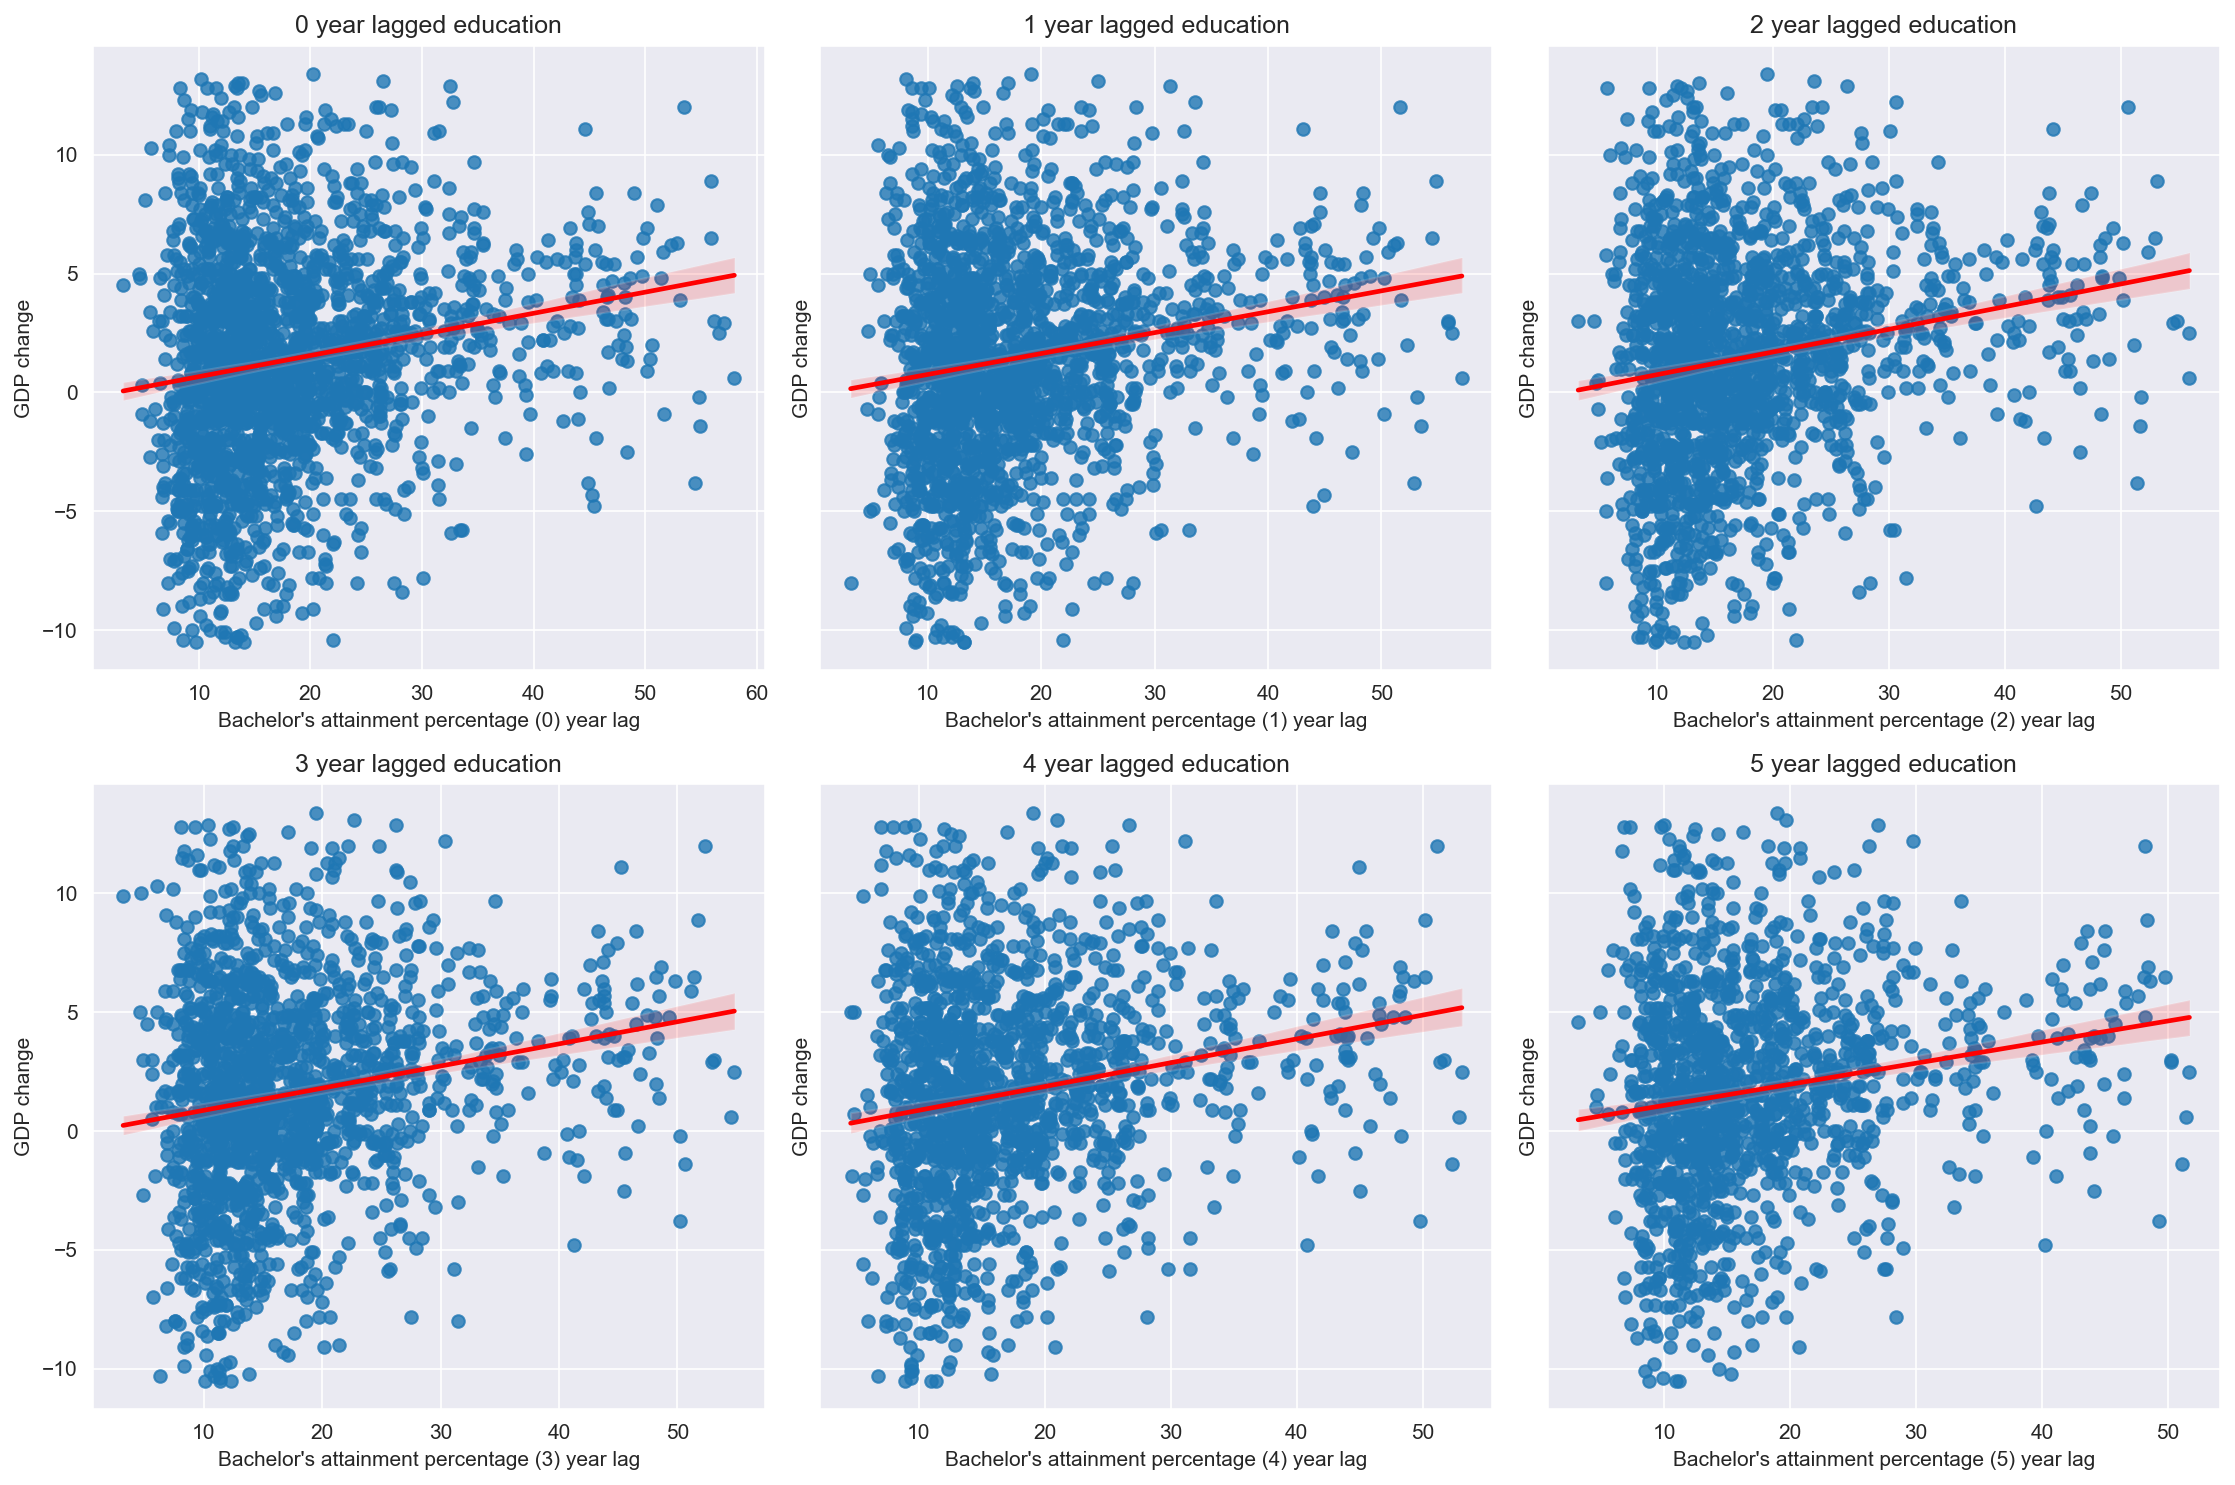

In [69]:
# Generate lagged education features
lag = 5
lagged_df = create_lagged_education_df(education_gdp_df, lag, "County", PREDICTOR_COLUMN)
cleaned_lagged_df = remove_outliers_iqr(lagged_df, TARGET_COLUMN, 1.5)

# Display lagged education scatter plots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10), sharex=False, sharey=True, dpi=150)
axes_flat = axes.flatten()
display_lagged_scatter_plots(cleaned_lagged_df, lag, TARGET_COLUMN, axes_flat)
plt.tight_layout()
plt.show()

### The Results

The scatter plots provide an initial look into the predictive power—or lack thereof—of educational attainment on annual GDP growth. Several key observations emerge:

* Statistical Dispersion: The "cloud" of data points is highly dispersed across all 159 counties. This high variance suggests that while a relationship exists, it is subject to significant "noise" from other economic variables (e.g., industry shocks, interest rates, or local policy changes).

* Weak Linear Signal: The regression lines across all six plots maintain a consistently shallow, positive slope. With correlation coefficients (r) stagnating around 0.18, education level appears to be a "weak" linear predictor of annual growth.

* Temporal Invariance: Interestingly, increasing the lag from 0 to 5 years does not significantly "tighten" the scatter spread or dramatically improve the correlation. This suggests that the relationship between human capital and growth is structural (a permanent foundation) rather than dynamic (a specific trigger that sets off growth after X years). This result is very strongly supported by the next graph, which displays how the correlation between the two aforementioned parameters changes with increased lag.

### Modelling Significance

These results indicate that **a simple Linear Regression model will likely underperform. However, the consistent positive slope—no matter how slight—confirms that a signal does exist**. The next phase of this project will utilize non-linear algorithms (such as Random Forest or Gradient Boosting) to determine if these models can extract complex, high-dimensional patterns that simple linear correlations fail to capture.

## Correlation vs. Differing Lag Levels Graph

While the scatter plots provided a visual sense of the data's dispersion, the line graph below offers a precise mathematical summary of the relationship. By plotting the Pearson Correlation Coefficient (r) against each lag year (0–5), we can definitively see if a "peak" exists.

### Goals of this Visualization

* Identify the Apex: Pinpoint exactly which lag year provides the strongest signal for our model.

* Assess Sensitivity: Determine if the correlation is stable over time or if it decays rapidly as the lag increases.

* Benchmark for Modeling: This graph establishes the "limit" of linear predictability. Any performance gain achieved by our eventual Machine Learning models over these r values will represent the "Non-Linear Lift" provided by more complex algorithms.

### Visualization Parameters

* **X-Axis:** Lag level.

* **Y-Axis:** Pearson correlation between education level and GDP at a given lag.

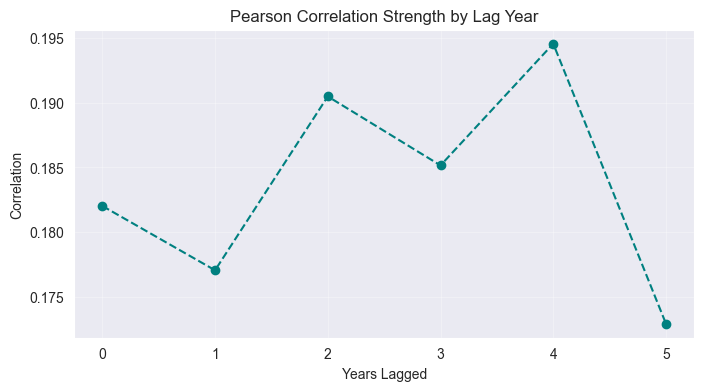

In [70]:
pearson_corrs = calculate_education_gdp_correlation(cleaned_lagged_df, lag, TARGET_COLUMN, "pearson")
display_education_lags_correlation(pearson_corrs, lag, "pearson")

### The Results

While the scatter plots showed significant dispersion, this line graph synthesizes those results to reveal the temporal "sweet spot" for our predictor. And with this, we have the following insights:

* **Identification of the 4-Year Peak:** The Pearson correlation doesn't stay flat; it trends upward as we increase the lag, peaking at 4 years. This suggests that the economic "return on education" in Georgia counties may take roughly four years to fully circulate into measurable GDP growth.

* **Non-Linear Volatility:** The "jagged" nature of the line—dipping at 1 year and 3 years before rising again—highlights the complexity of county-level data. This fluctuation confirms that this relationship is being influenced by external economic cycles or noise.

* **Sub-0.20 Correlation:** Even at its peak, the correlation remains below 0.20. This empirically proves that while educational attainment is a relevant factor, it is likely part of a much larger, multi-variable equation.

### Strategic Conclusion for Modeling:

Because the highest signal-to-noise ratio occurs at the 4-year lag, this specific feature will be prioritized in our feature engineering phase. The presence of a clear peak justifies moving beyond simple correlation and into Machine Learning, where we can combine this 4-year lagged signal with other predictors to improve accuracy.